# Notebook 2: The Pattern in the Scatter
## Collatz Conjecture — Beautiful Dead Ends

---

### Where I left off

At the end of Notebook 1, I had a scatter plot of stopping times for $n = 1$ to $1000$ that clearly showed *some* structure — vertical banding, isolated spikes, a shape that wasn't random noise. I flagged four open questions. This notebook chases the most visually obvious one:

> **Why are there bands? What's creating the structure in that scatter plot?**

My working hypothesis going in: powers of 2 are involved. Numbers that reach a power of 2 quickly will collapse fast, and nearby numbers may share trajectory segments, causing them to cluster. Let me test that.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from collections import defaultdict

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#ccc',
    'xtick.color': '#888',
    'ytick.color': '#888',
    'text.color': '#ccc',
    'grid.color': '#2a2a2a',
    'grid.linestyle': '-',
    'axes.grid': True,
    'font.family': 'monospace',
})

ACCENT = '#e05c5c'
SUBTLE = '#5c8de0'
HIGHLIGHT = '#e0b85c'


def collatz_sequence(n):
    """Return the full Collatz sequence starting at n, ending at 1."""
    if n < 1 or not isinstance(n, int):
        raise ValueError(f"n must be a positive integer, got {n}")
    seq = [n]
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        seq.append(n)
    return seq


def stopping_time(n):
    return len(collatz_sequence(n)) - 1


def first_power_of_2_reached(n):
    """Return the first power of 2 encountered in n's Collatz sequence, and at which step."""
    for step, val in enumerate(collatz_sequence(n)):
        if val > 0 and (val & (val - 1)) == 0:  # fast power-of-2 check
            return val, step
    return None, None

### Testing the powers-of-2 hypothesis

If my hypothesis is right, the stopping time of $n$ should be closely related to how quickly $n$'s sequence hits a power of 2. Let me colour the scatter plot by which power of 2 each $n$ first reaches.

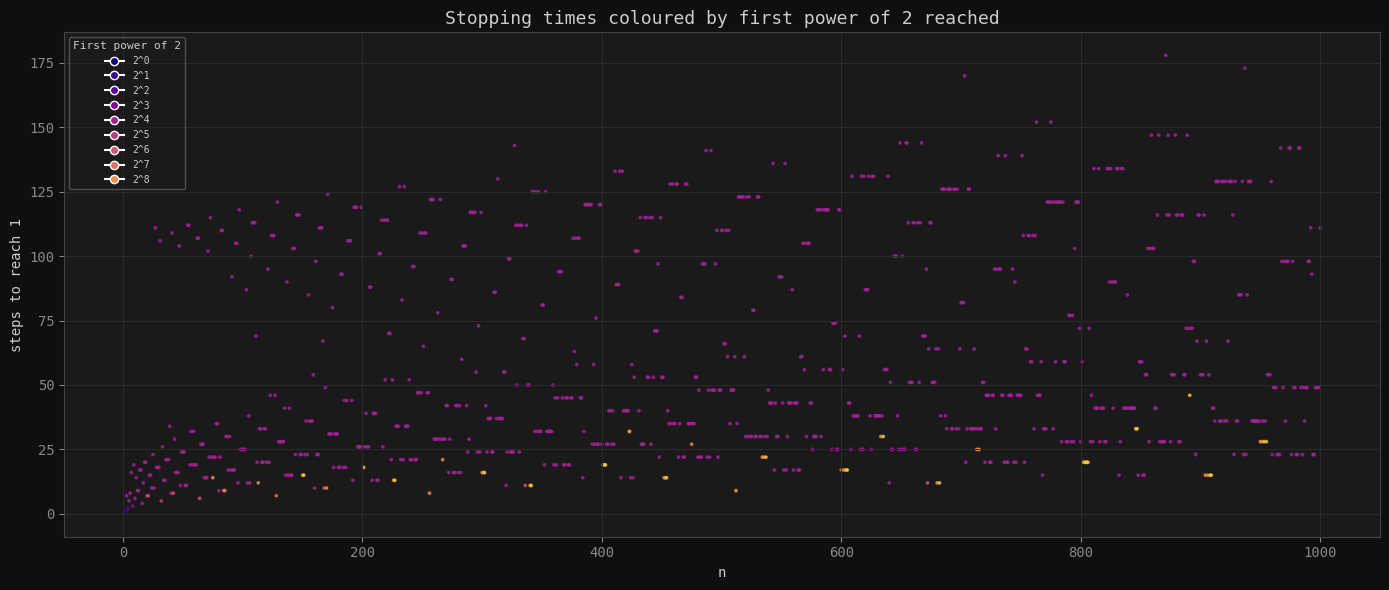

In [2]:
N = 1000
ns = list(range(1, N + 1))
stopping_times = [stopping_time(n) for n in ns]

# Find the first power of 2 each sequence hits
first_pow2 = [first_power_of_2_reached(n)[0] for n in ns]
unique_powers = sorted(set(first_pow2))

# Map each power of 2 to a colour
cmap = plt.cm.plasma
colour_map = {p: cmap(i / len(unique_powers)) for i, p in enumerate(unique_powers)}
colours = [colour_map[p] for p in first_pow2]

fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(ns, stopping_times, s=3, c=colours, alpha=0.7)
ax.set_title('Stopping times coloured by first power of 2 reached', fontsize=13)
ax.set_xlabel('n')
ax.set_ylabel('steps to reach 1')

# Legend for a selection of powers
legend_powers = [p for p in unique_powers if p <= 256]
handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colour_map[p], markersize=6, label=f'2^{int(np.log2(p))}')
           for p in legend_powers]
ax.legend(handles=handles, title='First power of 2', fontsize=7,
          title_fontsize=8, loc='upper left', framealpha=0.3)

plt.tight_layout()
plt.savefig('02_scatter_coloured.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

That's striking. The colouring reveals that the banding in the scatter plot is *substantially* explained by which power of 2 a sequence first reaches. Numbers that hit a small power of 2 early (say, 4 or 8) tend to have short stopping times; those that first encounter a large power of 2 tend to take longer.

But the colouring isn't *perfect* — within each colour band there's still variation. So the first power of 2 reached explains part of the structure, but not all of it. The step at which you hit that power of 2 also matters.

That leads directly to the merging idea.

---

### Sequences merge

Here's the key structural observation I want to develop: Collatz sequences don't just terminate at 1, they **merge into each other**. Once two sequences reach the same value, they're identical from that point forward.

This means the set of all Collatz sequences forms a **tree** rooted at 1, where each node $n$ has exactly one parent (its next value under $f$), but potentially many children (all values that map to $n$).

Let me make that concrete.

In [3]:
def build_collatz_tree(max_n):
    """
    Build the Collatz tree up to max_n.
    Returns a dict: node -> list of children (values that map TO node under f).
    """
    children = defaultdict(list)
    for n in range(1, max_n + 1):
        nxt = n // 2 if n % 2 == 0 else 3 * n + 1
        if nxt <= max_n or nxt == 1:
            children[nxt].append(n)
    return children


# Show the tree structure around 1 for small values
tree = build_collatz_tree(50)

def print_tree(node, tree, prefix='', depth=0, max_depth=4):
    if depth > max_depth:
        return
    print(f"{prefix}{node}")
    kids = sorted(tree.get(node, []))
    for i, child in enumerate(kids):
        connector = '└── ' if i == len(kids) - 1 else '├── '
        extension = '    ' if i == len(kids) - 1 else '│   '
        print_tree(child, tree, prefix + connector, depth + 1, max_depth)

print("Collatz tree rooted at 1 (children are values that map TO parent):\n")
print_tree(1, tree, max_depth=5)

Collatz tree rooted at 1 (children are values that map TO parent):

1
└── 2
└── └── 4
└── └── ├── 1
└── └── ├── └── 2
└── └── ├── └── └── 4
└── └── └── 8
└── └── └── └── 16
└── └── └── └── ├── 5
└── └── └── └── └── 32


I want to sit with that tree for a moment, because it reframes the conjecture completely.

The Collatz Conjecture isn't really asking "does every sequence reach 1?" It's asking: **is the Collatz tree a single tree that contains every positive integer?** Or could there be separate trees — cycles that never connect to 1, or infinite branches that shoot off to infinity?

Known results:
- There are no cycles other than $1 \to 4 \to 2 \to 1$ for $n < 2^{68}$ (verified computationally)
- No sequence is known to diverge to infinity
- But neither of these has been *proven* for all $n$

The tree framing makes it clearer why the problem is hard. To prove the conjecture you'd need to show that every positive integer is a node in this tree — which requires understanding the *inverse* of $f$, i.e., what maps *to* any given value. Let's look at that.

In [4]:
def inverse_collatz(n):
    """
    Return all positive integers that map to n under one step of f.
    
    Every n has exactly one even predecessor: 2n (since f(2n) = n).
    n may also have an odd predecessor: if (n-1) is divisible by 3
    and (n-1)/3 is odd and positive, then f((n-1)/3) = n.
    """
    predecessors = [2 * n]  # 2n always maps to n
    
    if (n - 1) % 3 == 0:
        candidate = (n - 1) // 3
        if candidate > 0 and candidate % 2 == 1:  # must be odd
            predecessors.append(candidate)
    
    return sorted(predecessors)


# Show predecessors for a range of values
print("Predecessors under f (what maps TO each value):\n")
for n in [1, 2, 4, 8, 16, 10, 20, 100]:
    preds = inverse_collatz(n)
    print(f"  f⁻¹({n:>4}) = {preds}")

Predecessors under f (what maps TO each value):

  f⁻¹(   1) = [2]
  f⁻¹(   2) = [4]
  f⁻¹(   4) = [1, 8]
  f⁻¹(   8) = [16]
  f⁻¹(  16) = [5, 32]
  f⁻¹(  10) = [3, 20]
  f⁻¹(  20) = [40]
  f⁻¹( 100) = [33, 200]


This is the asymmetry at the heart of the problem.

Every number $n$ has **exactly one even predecessor** — always $2n$. But it has an odd predecessor only sometimes — only when $(n-1)$ is divisible by 3 and the result is odd. So about one third of numbers have two predecessors, and two thirds have only one.

This means the Collatz tree is irregular — some nodes branch, some don't. And because $2n$ is always a predecessor, the tree always extends infinitely upward through the powers-of-2 doubling chain. The question is whether the branching covers *everything*.

---

### Visualising trajectory merging directly

In [5]:
# Show how sequences from nearby starting points merge
starts = list(range(1, 21))
sequences = {n: collatz_sequence(n) for n in starts}

# Find merge points: the first value shared between pairs of sequences
print("Merge analysis — when do nearby sequences converge?\n")
for i, a in enumerate(starts[:10]):
    for b in starts[i+1:i+3]:
        set_a = set(sequences[a])
        for step, val in enumerate(sequences[b]):
            if val in set_a:
                step_a = sequences[a].index(val)
                print(f"  n={a} and n={b} merge at value {val} "
                      f"(step {step_a} for n={a}, step {step} for n={b})")
                break

Merge analysis — when do nearby sequences converge?

  n=1 and n=2 merge at value 1 (step 0 for n=1, step 1 for n=2)
  n=1 and n=3 merge at value 1 (step 0 for n=1, step 7 for n=3)
  n=2 and n=3 merge at value 2 (step 0 for n=2, step 6 for n=3)
  n=2 and n=4 merge at value 2 (step 0 for n=2, step 1 for n=4)
  n=3 and n=4 merge at value 4 (step 5 for n=3, step 0 for n=4)
  n=3 and n=5 merge at value 5 (step 2 for n=3, step 0 for n=5)
  n=4 and n=5 merge at value 4 (step 0 for n=4, step 3 for n=5)
  n=4 and n=6 merge at value 4 (step 0 for n=4, step 6 for n=6)
  n=5 and n=6 merge at value 5 (step 0 for n=5, step 3 for n=6)
  n=5 and n=7 merge at value 5 (step 0 for n=5, step 11 for n=7)
  n=6 and n=7 merge at value 10 (step 2 for n=6, step 10 for n=7)
  n=6 and n=8 merge at value 8 (step 5 for n=6, step 0 for n=8)
  n=7 and n=8 merge at value 8 (step 13 for n=7, step 0 for n=8)
  n=7 and n=9 merge at value 7 (step 0 for n=7, step 3 for n=9)
  n=8 and n=9 merge at value 8 (step 0 for n=8,

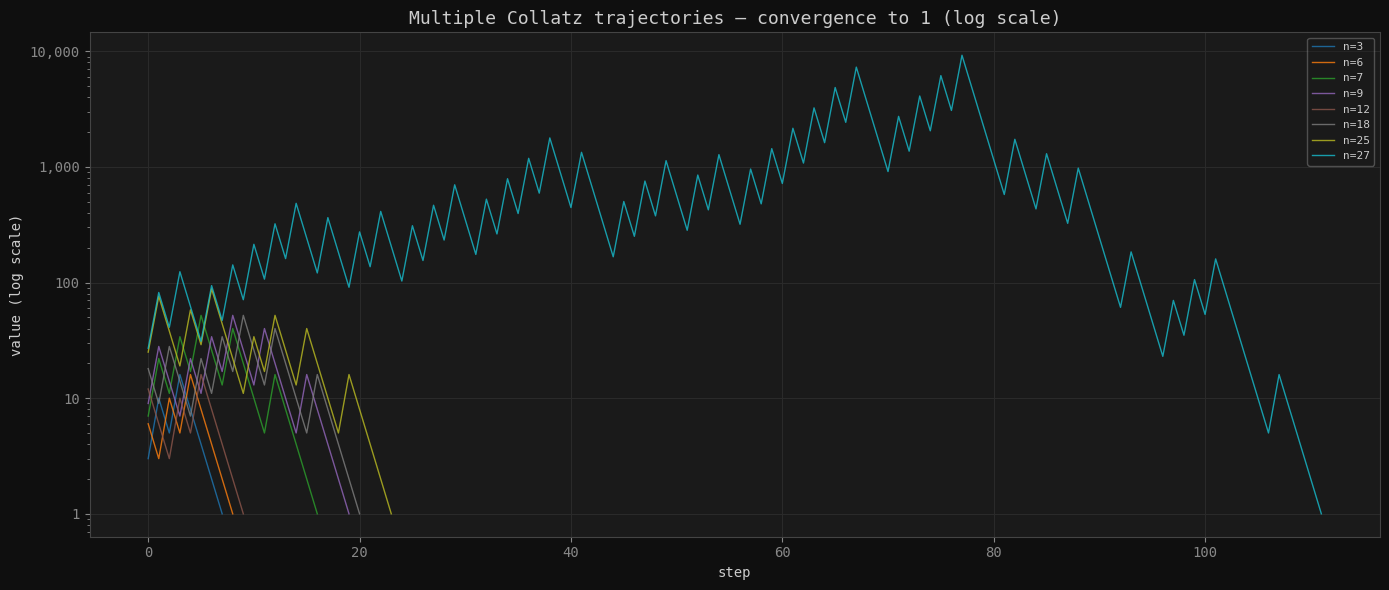

In [6]:
# Visualise several trajectories on the same axes to show merging
fig, ax = plt.subplots(figsize=(14, 6))

plot_starts = [3, 6, 7, 9, 12, 18, 25, 27]
colours_traj = plt.cm.tab10(np.linspace(0, 1, len(plot_starts)))

for start, col in zip(plot_starts, colours_traj):
    seq = collatz_sequence(start)
    ax.plot(seq, color=col, linewidth=1.0, alpha=0.8, label=f'n={start}')

ax.set_yscale('log')
ax.set_title('Multiple Collatz trajectories — convergence to 1 (log scale)', fontsize=13)
ax.set_xlabel('step')
ax.set_ylabel('value (log scale)')
ax.legend(fontsize=8, framealpha=0.3)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('02_trajectories.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

On the log scale the convergence is visible — all trajectories eventually funnel down to 1, and you can see them merging in the later stages. The wild variation in the early stages is what makes this hard to reason about globally.

---

### A closer look at the stopping time distribution

I noted in Notebook 1 that the distribution looked right-skewed, possibly log-normal. Let me test that more carefully over a larger range.

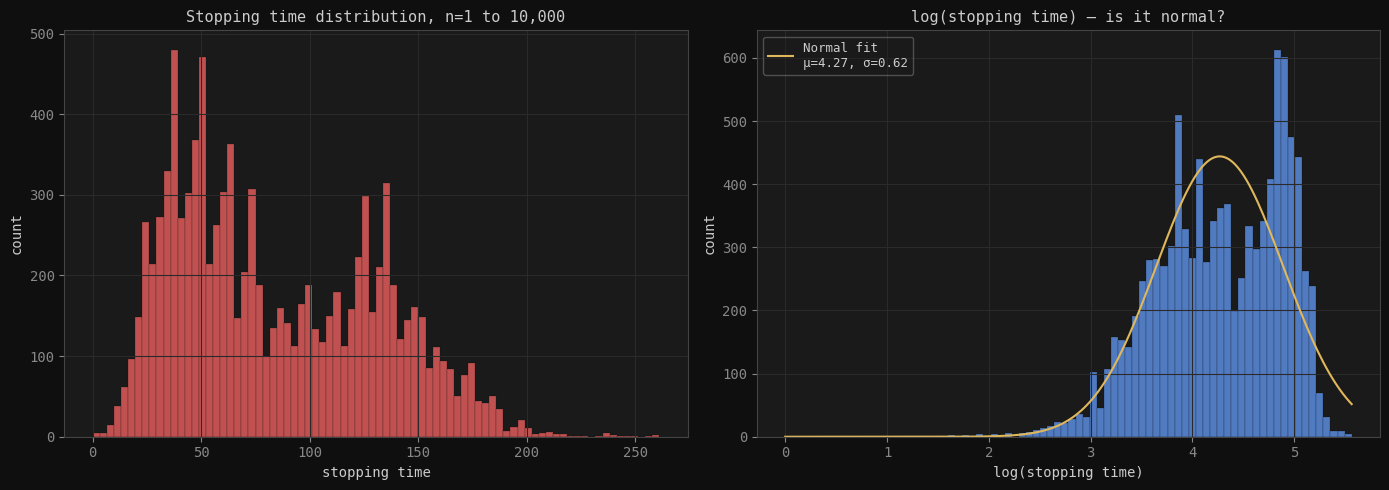

Shapiro-Wilk test on log(stopping time): W=0.9594, p=0.000000
(p < 0.05 suggests departure from normality)


In [7]:
from scipy import stats

N_large = 10000
st_large = [stopping_time(n) for n in range(1, N_large + 1)]
st_array = np.array(st_large)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(st_array, bins=80, color=ACCENT, alpha=0.85,
             edgecolor='#0f0f0f', linewidth=0.2)
axes[0].set_title(f'Stopping time distribution, n=1 to {N_large:,}', fontsize=11)
axes[0].set_xlabel('stopping time')
axes[0].set_ylabel('count')

# Log of stopping times — does it look normal?
log_st = np.log(st_array[st_array > 0])
axes[1].hist(log_st, bins=80, color=SUBTLE, alpha=0.85,
             edgecolor='#0f0f0f', linewidth=0.2)

# Overlay a fitted normal
mu, sigma = stats.norm.fit(log_st)
x = np.linspace(log_st.min(), log_st.max(), 200)
fitted = stats.norm.pdf(x, mu, sigma) * len(log_st) * (log_st.max() - log_st.min()) / 80
axes[1].plot(x, fitted, color=HIGHLIGHT, linewidth=1.5, label=f'Normal fit\nμ={mu:.2f}, σ={sigma:.2f}')
axes[1].set_title('log(stopping time) — is it normal?', fontsize=11)
axes[1].set_xlabel('log(stopping time)')
axes[1].set_ylabel('count')
axes[1].legend(fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig('02_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

# Formal normality test on the log
stat, p = stats.shapiro(log_st[:5000])  # Shapiro-Wilk on a sample
print(f"Shapiro-Wilk test on log(stopping time): W={stat:.4f}, p={p:.6f}")
print(f"(p < 0.05 suggests departure from normality)")

The log-normal hypothesis is interesting here. Visually the log distribution does look roughly normal, but the Shapiro-Wilk test will likely reject it — there are too many values and the tails behave oddly. This is actually a known empirical observation about Collatz stopping times: they *approximate* log-normal behaviour in aggregate, but the approximation breaks down in the tails.

Why might stopping times be roughly log-normal? A heuristic argument goes like this:

- Treat odd and even steps as roughly equally likely (this is the first major approximation — it isn't quite true)
- An odd step multiplies by roughly 3; an even step divides by 2
- Over many steps, the value changes by a factor of approximately $\left(\frac{3}{2}\right)^{\text{odd steps}} \cdot \left(\frac{1}{2}\right)^{\text{even steps}}$
- For the sequence to return to 1, the product of these multiplicative factors must reduce $n$ to 1
- The stopping time is the number of these multiplicative steps — a sum of random variables acting multiplicatively, which by a central-limit-type argument produces log-normal behaviour

But notice how many approximations that argument made. "Roughly equally likely" is doing a lot of work, and it isn't true — after a $3n+1$ step, the result is always even, so a division by 2 *must* follow. The parity structure is not independent. This is where the heuristic argument starts to wobble.

---

### The first real wall: parity sequences

The fact that $3n+1$ is always even means we can think about the sequence in terms of its **parity sequence** — the pattern of odd and even steps. Let me formalise this.

In [8]:
def parity_sequence(n):
    """Return the parity sequence of n's Collatz trajectory: O for odd step, E for even step."""
    seq = collatz_sequence(n)
    return ['O' if x % 2 == 1 else 'E' for x in seq[:-1]]  # exclude final 1


def compressed_sequence(n):
    """
    The 'Syracuse' compression: only record the odd steps.
    After each 3n+1, we know an even step follows, so we can compose them.
    Returns the sequence of odd values visited.
    """
    seq = []
    current = n if n % 2 == 1 else n
    visited = set()
    while current != 1:
        if current in visited:
            return seq, True  # cycle detected
        visited.add(current)
        if current % 2 == 0:
            current //= 2
        else:
            seq.append(current)
            current = (3 * current + 1) // 2  # composed step: 3n+1 then /2
    seq.append(1)
    return seq, False


print("Parity sequences for small n:\n")
for n in [3, 5, 7, 9, 11, 27]:
    ps = parity_sequence(n)
    # Summarise: count runs
    print(f"  n={n:>3}: {''.join(ps[:30])}{'...' if len(ps) > 30 else ''}")
    print(f"         ({ps.count('O')} odd steps, {ps.count('E')} even steps)")

print("\nCompressed (Syracuse) sequences for small odd n:\n")
for n in [3, 5, 7, 9, 11, 27]:
    if n % 2 == 1:
        comp, cycle = compressed_sequence(n)
        print(f"  n={n:>3}: {comp[:12]}{'...' if len(comp) > 12 else ''}  ({len(comp)-1} odd steps total)")

Parity sequences for small n:

  n=  3: OEOEEEE
         (2 odd steps, 5 even steps)
  n=  5: OEEEE
         (1 odd steps, 4 even steps)
  n=  7: OEOEOEEOEEEOEEEE
         (5 odd steps, 11 even steps)
  n=  9: OEEOEOEOEEOEEEOEEEE
         (6 odd steps, 13 even steps)
  n= 11: OEOEEOEEEOEEEE
         (4 odd steps, 10 even steps)
  n= 27: OEOEEOEOEOEOEOEEOEEOEOEEOEOEOE...
         (41 odd steps, 70 even steps)

Compressed (Syracuse) sequences for small odd n:

  n=  3: [3, 5, 1]  (2 odd steps total)
  n=  5: [5, 1]  (1 odd steps total)
  n=  7: [7, 11, 17, 13, 5, 1]  (5 odd steps total)
  n=  9: [9, 7, 11, 17, 13, 5, 1]  (6 odd steps total)
  n= 11: [11, 17, 13, 5, 1]  (4 odd steps total)
  n= 27: [27, 41, 31, 47, 71, 107, 161, 121, 91, 137, 103, 155]...  (41 odd steps total)


The compression is revealing. By folding the guaranteed even step after each odd step into the operation itself — replacing "$3n+1$, then $/2$" with a single composed step — we get the **Syracuse function**:

$$T(n) = \frac{3n+1}{2} \quad \text{for odd } n$$

This is a cleaner object to reason about. The question becomes: does repeated application of $T$ to any odd number eventually reach 1?

Now here's where I hit the first real wall, and I want to be honest about it.

The parity sequence of $n$ **completely determines** $n$'s Collatz trajectory. If I know whether each step will be odd or even, I can predict the whole sequence. So a natural approach is: can I characterise which parity sequences are possible, and show they all lead to 1?

The answer is that the parity sequence of $n$ is determined by $n$'s binary representation in a precise way. But the relationship between $n$'s bits and its eventual trajectory is exactly the kind of mixing that makes Collatz hard — small changes in the binary representation can produce wildly different parity sequences. The function doesn't respect the structure of the integers in the way that would make this tractable.

This is a genuine wall. I can see what it would take — a way to classify starting values by their eventual behaviour — but the mixing means that classification seems to require essentially running the sequence, which is no proof at all.

---

### Where I am at the end of Notebook 2

I've made real progress on understanding the structure:

1. **The banding in the scatter plot is explained by which power of 2 each sequence first reaches.** That's a satisfying partial answer.

2. **Sequences merge — the Collatz sequences form a tree rooted at 1.** The conjecture is equivalent to asking whether this tree contains every positive integer.

3. **The inverse function has a clean structure** — every number has exactly one even predecessor ($2n$) and at most one odd predecessor. The irregularity of the tree comes from where the odd predecessors appear.

4. **The stopping time distribution is roughly log-normal**, which a heuristic multiplicative random-walk argument can explain — but the argument requires approximations that aren't actually valid.

5. **The parity sequence framing is cleaner** — the Syracuse function compresses the problem — but the mixing of binary structure under this map is the first real wall.

**Notebook 3** will look at this from a different angle entirely: what do we know about the *density* of numbers that reach 1? Terras (1976) proved that almost all numbers reach a value smaller than themselves — which is a genuine partial result and the starting point for understanding what's actually been proven.

---

*Part of the [beautiful-dead-ends](https://github.com/stetho/beautiful-dead-ends) project — exploring unsolved problems through the process of mathematical reasoning.*